Ukuran Dataset: (202, 29)
  Countries and areas  Latitude   Longitude  OOSR_Pre0Primary_Age_Male  \
0         Afghanistan  33.939110  67.709953                          0   
1             Albania  41.153332  20.168331                          4   
2             Algeria  28.033886   1.659626                          0   
3             Andorra  42.506285   1.521801                          0   
4              Angola  11.202692  17.873887                         31   

   OOSR_Pre0Primary_Age_Female  OOSR_Primary_Age_Male  \
0                            0                      0   
1                            2                      6   
2                            0                      0   
3                            0                      0   
4                           39                      0   

   OOSR_Primary_Age_Female  OOSR_Lower_Secondary_Age_Male  \
0                        0                              0   
1                        3                              6   
2  

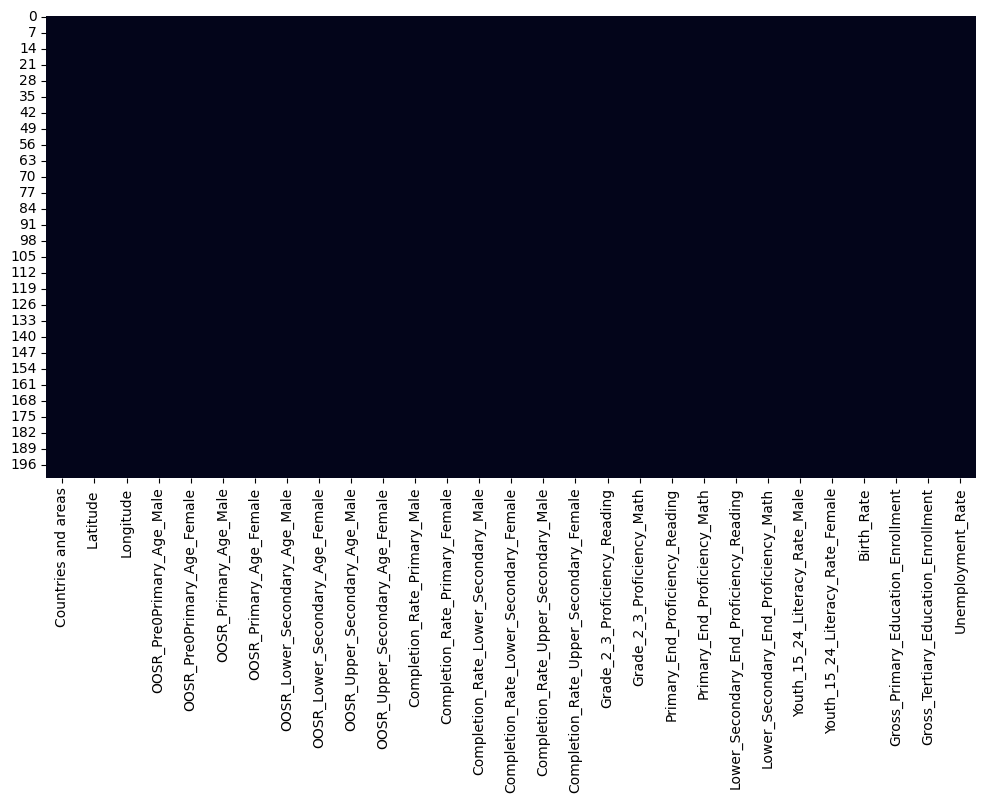

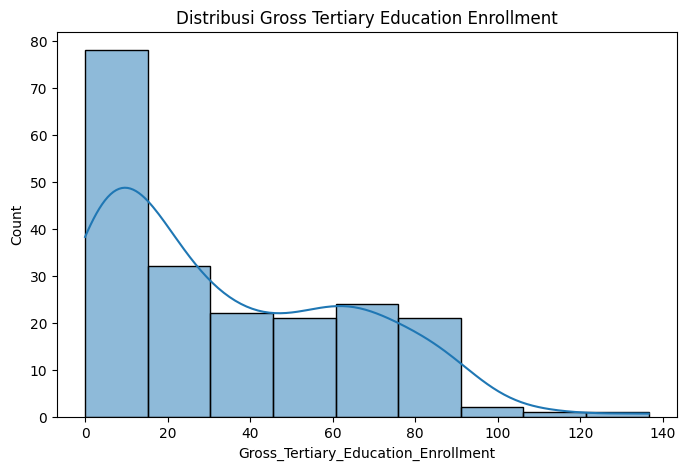

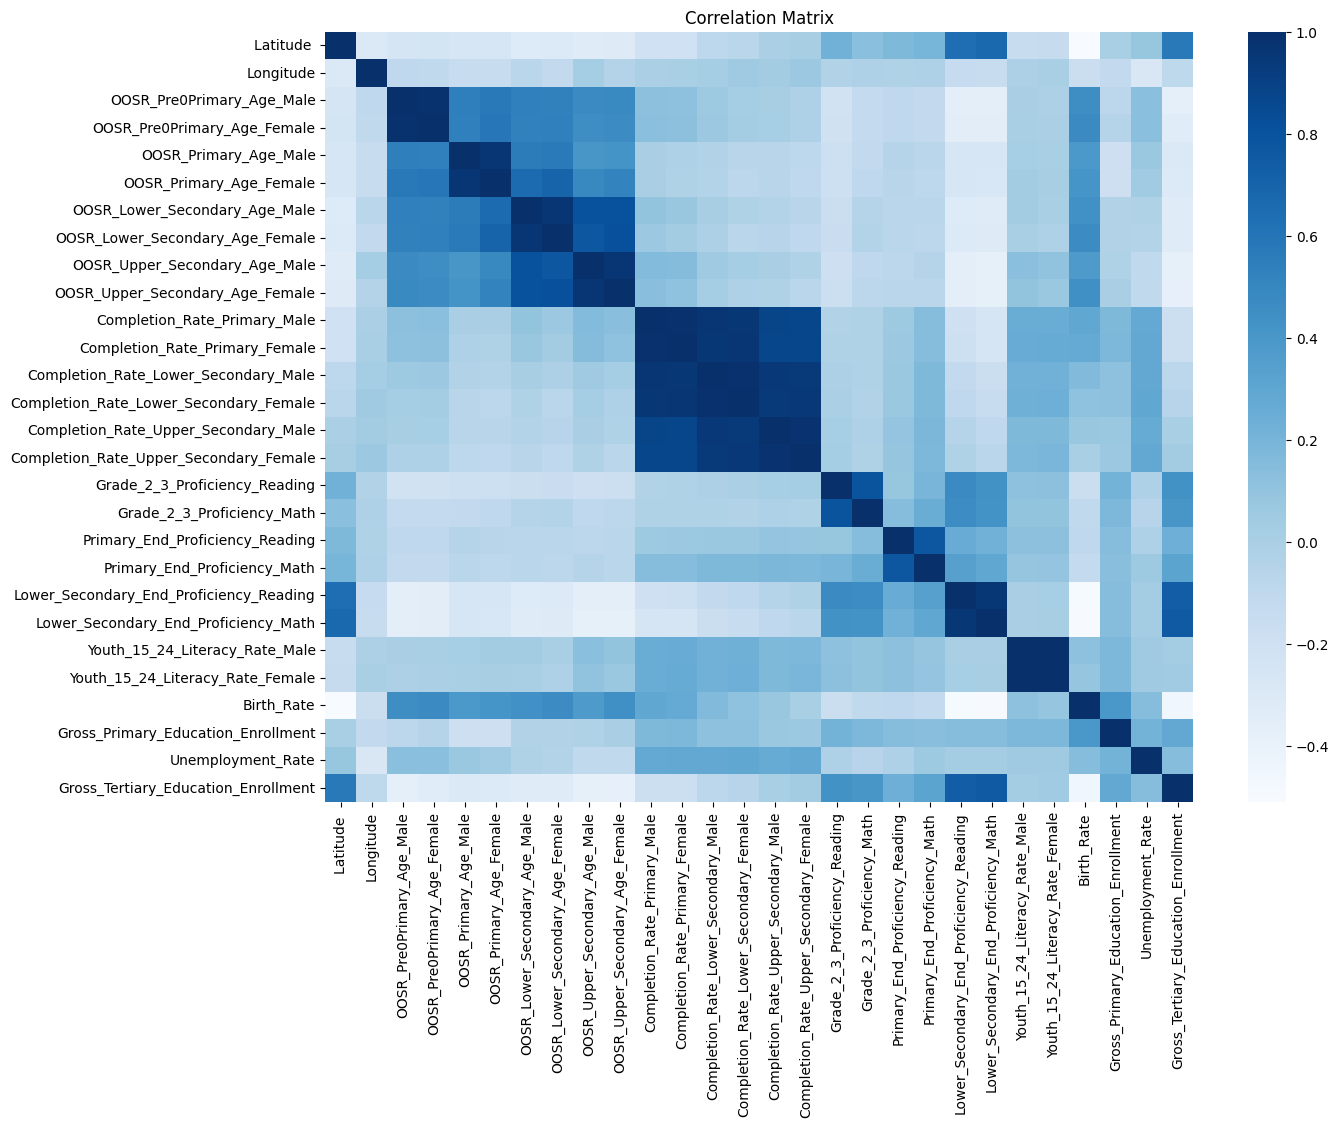


===== HASIL EVALUASI =====
MAE : 17.167731707317074
MSE : 507.3843344024393
RMSE: 22.525193326638494
R2  : 0.4397863742694752


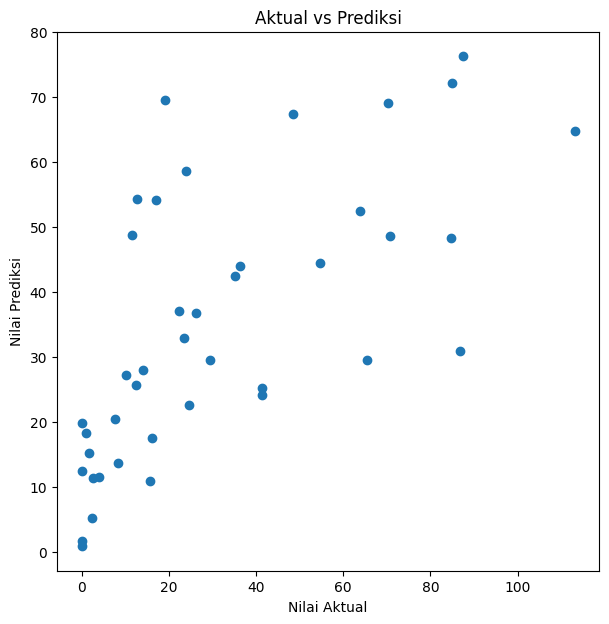


10 Feature Terpenting
                                    Feature  Importance
21     Lower_Secondary_End_Proficiency_Math    0.485726
20  Lower_Secondary_End_Proficiency_Reading    0.124150
0                                 Latitude     0.080866
24                               Birth_Rate    0.068415
26                        Unemployment_Rate    0.058290
25       Gross_Primary_Education_Enrollment    0.036201
1                                 Longitude    0.024061
8             OOSR_Upper_Secondary_Age_Male    0.016284
9           OOSR_Upper_Secondary_Age_Female    0.014308
3               OOSR_Pre0Primary_Age_Female    0.010570


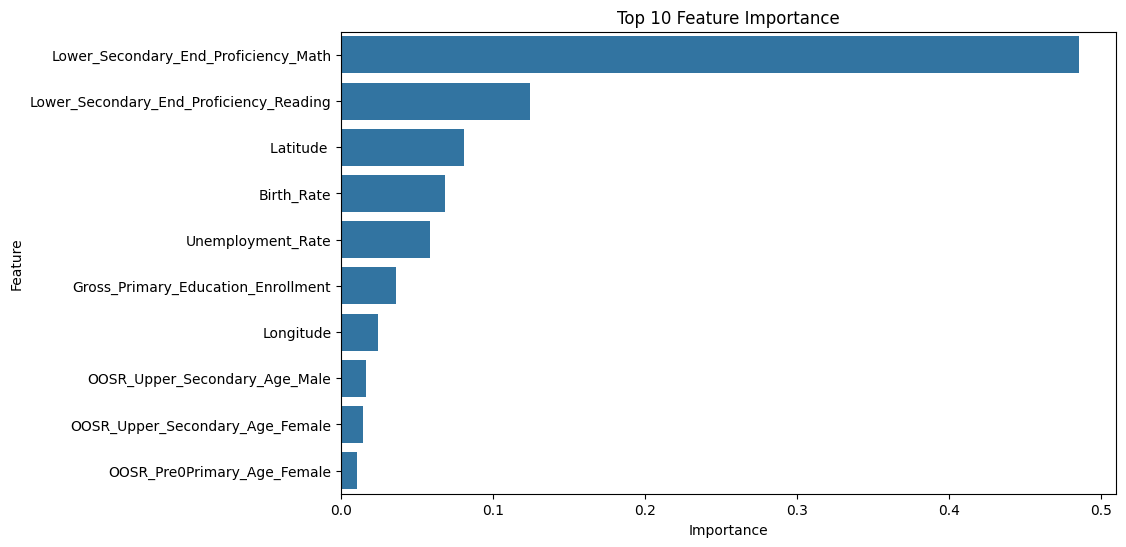


Model berhasil disimpan sebagai education_model.pkl

Contoh Prediksi:
[13.5875]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("/content/drive/MyDrive/MyFile/Global_Education.csv", encoding="latin1")

print("Ukuran Dataset:", df.shape)
print(df.head())

print("\nInformasi Dataset")
print(df.info())

print("\nMissing Value")
print(df.isnull().sum())

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

target = "Gross_Tertiary_Education_Enrollment"

X = df.drop(columns=[target])

X = X.select_dtypes(include=np.number)

y = df[target]

X = X.replace(["..", "...", " "], np.nan)
y = y.replace(["..", "...", " "], np.nan)

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

data = pd.concat([X, y], axis=1)

data = data.dropna(subset=[target])

X = data.drop(columns=[target])
y = data[target]

plt.figure(figsize=(8,5))
sns.histplot(y, kde=True)
plt.title("Distribusi Gross Tertiary Education Enrollment")
plt.show()

plt.figure(figsize=(14,10))
sns.heatmap(data.corr(numeric_only=True), cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, X.columns)
    ]
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== HASIL EVALUASI =====")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred)
plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.title("Aktual vs Prediksi")
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": pipeline.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n10 Feature Terpenting")
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Feature Importance")
plt.show()

joblib.dump(pipeline, "education_model.pkl")

print("\nModel berhasil disimpan sebagai education_model.pkl")

sample = X.iloc[[0]]

prediction = pipeline.predict(sample)

print("\nContoh Prediksi:")
print(prediction)